In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
dataset_path = '/content/drive/MyDrive/OvarianCancer'

In [ ]:
# List the categories to verify
categories = ['Clear_Cell', 'Endometri', 'Mucinous', 'Non_Cancerous', 'Serous']

In [ ]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img

# 1. Paths and Categories
dataset_path = '/content/drive/MyDrive/OvarianCancer'
output_path = '/content/Augmented_OvarianCancer'  # Saved locally in Colab for speed
categories = ['Clear_Cell', 'Endometri', 'Mucinous', 'Non_Cancerous', 'Serous']

# 2. Initialize ImageDataGenerator with Paper Parameters
# 40 deg rotation, 20% shear, 20% zoom, horizontal flip, 50%-150% brightness
datagen = ImageDataGenerator(
    rotation_range=40,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=(0.5, 1.5),
    fill_mode='nearest'
)

# 3. Process each category
print("Starting augmentation process...")

total_count = 0
category_stats = {}

for category in categories:
    input_dir = os.path.join(dataset_path, category)
    output_dir = os.path.join(output_path, category)

    # Create the output category folder if it doesn't exist
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    # Get all image files in the folder
    images = [f for f in os.listdir(input_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    category_count = 0
    print(f"Processing category: {category} ({len(images)} original images)")

    for img_name in images:
        # Load image and resize to 227x227 as required by the paper's model
        img_path = os.path.join(input_dir, img_name)
        img = load_img(img_path, target_size=(227, 227))

        x = img_to_array(img)
        x = x.reshape((1,) + x.shape) # Reshape to (1, 227, 227, 3)

        # Generate 50 augmented samples for every 1 original image
        i = 0
        for batch in datagen.flow(x,
                                  batch_size=1,
                                  save_to_dir=output_dir,
                                  save_prefix=category[:3], # e.g., 'Ser' for Serous
                                  save_format='jpg'):
            i += 1
            category_count += 1
            if i >= 50:
                break

    category_stats[category] = category_count
    total_count += category_count

# 4. Final Summary Report
print("\n" + "="*40)
print("AUGMENTATION COMPLETE")
print("="*40)
for cat, count in category_stats.items():
    print(f"{cat.ljust(15)}: {count:,} images")
print("-" * 40)
print(f"TOTAL IMAGES   : {total_count:,}")
print("=" * 40)

Starting augmentation process...
Processing category: Clear_Cell (99 original images)
Processing category: Endometri (98 original images)
Processing category: Mucinous (100 original images)
Processing category: Non_Cancerous (100 original images)
Processing category: Serous (100 original images)

AUGMENTATION COMPLETE
Clear_Cell     : 4,950 images
Endometri      : 4,900 images
Mucinous       : 5,000 images
Non_Cancerous  : 5,000 images
Serous         : 5,000 images
----------------------------------------
TOTAL IMAGES   : 24,850


In [ ]:
import shutil

src = "/content/Augmented_OvarianCancer"
dst = "/content/drive/MyDrive/Augmented_OvarianCancer"

shutil.copytree(src, dst)

print("Augmented dataset successfully saved to Google Drive!")


Augmented dataset successfully saved to Google Drive!


In [ ]:
import os

drive_aug_path = "/content/drive/MyDrive/Augmented_OvarianCancer"

total = 0

print("\nImage count per category:\n")

for folder in os.listdir(drive_aug_path):
    folder_path = os.path.join(drive_aug_path, folder)

    if os.path.isdir(folder_path):
        count = len([
            f for f in os.listdir(folder_path)
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))
        ])

        print(f"{folder.ljust(15)} : {count:,}")
        total += count

print("-" * 40)
print(f"TOTAL IMAGES      : {total:,}")
print("-" * 40)



Image count per category:

Non_Cancerous   : 3,885
Mucinous        : 3,871
Serous          : 3,960
Endometri       : 3,842
Clear_Cell      : 3,913
----------------------------------------
TOTAL IMAGES      : 19,471
----------------------------------------


In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split

SOURCE_DIR = "/content/drive/MyDrive/Augmented_OvarianCancer"
BASE_DIR = "/content/drive/MyDrive/split_data"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR   = os.path.join(BASE_DIR, "val")
TEST_DIR  = os.path.join(BASE_DIR, "test")

os.makedirs(TRAIN_DIR, exist_ok=True)
os.makedirs(VAL_DIR, exist_ok=True)
os.makedirs(TEST_DIR, exist_ok=True)

classes = os.listdir(SOURCE_DIR)

for cls in classes:
    cls_path = os.path.join(SOURCE_DIR, cls)
    images = [f for f in os.listdir(cls_path)
              if f.lower().endswith(('.jpg','.png','.jpeg'))]

    # 70% Train, 30% temp
    train_imgs, temp_imgs = train_test_split(
        images, test_size=0.30
    )

    # Split remaining 30% → 15% Val + 15% Test
    val_imgs, test_imgs = train_test_split(
        temp_imgs, test_size=0.50
    )

    for folder in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
        os.makedirs(os.path.join(folder, cls), exist_ok=True)

    for img in train_imgs:
        shutil.copy(os.path.join(cls_path, img),
                    os.path.join(TRAIN_DIR, cls, img))

    for img in val_imgs:
        shutil.copy(os.path.join(cls_path, img),
                    os.path.join(VAL_DIR, cls, img))

    for img in test_imgs:
        shutil.copy(os.path.join(cls_path, img),
                    os.path.join(TEST_DIR, cls, img))

print("✅ 70/15/15 dataset split completed!")


✅ 70/15/15 dataset split completed!


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

BASE_DIR = "/content/drive/MyDrive/split_data"

TRAIN_PATH = BASE_DIR + "/train"
VAL_PATH   = BASE_DIR + "/val"
TEST_PATH  = BASE_DIR + "/test"

# Generators (no validation_split anymore)
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen   = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

# =================
# TRAIN (70%)
# =================
train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=(227, 227),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

# =================
# VALIDATION (15%)
# =================
val_generator = val_datagen.flow_from_directory(
    VAL_PATH,
    target_size=(227, 227),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

# =================
# TEST (15%)
# =================
test_generator = test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=(227, 227),
    batch_size=32,
    class_mode='categorical',
    shuffle=False   # important for confusion matrix
)

print("Training samples:", train_generator.samples)
print("Validation samples:", val_generator.samples)
print("Testing samples:", test_generator.samples)


Found 13628 images belonging to 5 classes.
Found 2921 images belonging to 5 classes.
Found 2922 images belonging to 5 classes.
Training samples: 13628
Validation samples: 2921
Testing samples: 2922


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

def create_kk_net(input_shape=(227, 227, 3), num_classes=5):
    model = models.Sequential(name="KK-Net")

    # Layer 1 & 2: 32 filters, 3x3 kernel [cite: 139]
    model.add(layers.Conv2D(32, (3, 3), activation='elu', input_shape=input_shape, padding='same'))
    model.add(layers.Conv2D(32, (3, 3), activation='elu', padding='same'))
    # Max-pooling 1: 2x2 window [cite: 141]
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Dropout(0.2)) # Table 1 dropout

    # Layer 3 & 4: 64 filters, 3x3 kernel [cite: 142]
    model.add(layers.Conv2D(64, (3, 3), activation='elu', padding='same'))
    model.add(layers.Conv2D(64, (3, 3), activation='elu', padding='same'))
    # Max-pooling 2: 2x2 window [cite: 142]
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Dropout(0.2))

    # Layer 5: 128 filters [cite: 146]
    model.add(layers.Conv2D(128, (3, 3), activation='elu', padding='same'))
    # Max-pooling 3: 2x2 window [cite: 146]
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Dropout(0.2))

    # Layer 6: 256 filters [cite: 148]
    model.add(layers.Conv2D(256, (3, 3), activation='elu', padding='same'))
    # Max-pooling 4: 2x2 window [cite: 148]
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Dropout(0.2))

    model.add(layers.Flatten()) # [cite: 152]

    # --- UPDATED SECTION START ---
    # We apply L2 regularization here to prevent the Dense layers from overfitting
    model.add(layers.Dense(32,
                           activation='elu',
                           kernel_regularizer=regularizers.l2(0.01))) # Add here
    model.add(layers.Dropout(0.4))

    model.add(layers.Dense(16,
                           activation='elu',
                           kernel_regularizer=regularizers.l2(0.01))) # Add here
    model.add(layers.Dropout(0.4))
    # Output layer: 5 neurons with Softmax [cite: 154, 156]
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

kk_net_model = create_kk_net()
kk_net_model.summary() # Verify total params are ~2 million [cite: 157]

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "KK-Net"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 227, 227, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 227, 227, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 113, 113, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 113, 113, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 113, 113, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 113, 113, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │     1,605,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,040,869 (7.79 MB)

 Trainable params: 2,040,869 (7.79 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# ================================
# 1. Compile Model
# ================================
kk_net_model.compile(
    optimizer=Adam(learning_rate=3e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)

# ================================
# 2. Reduce LR on Validation Loss
# ================================
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

# ================================
# 3. Early Stopping on Validation
# ================================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# ================================
# 4. Save Best Model (Validation Accuracy)
# ================================
checkpoint = ModelCheckpoint(
    'kk_net_best.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# ================================
# 5. Train Model
# ================================
history = kk_net_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=[checkpoint, early_stop, lr_scheduler]
)



/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
426/426 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.3529 - loss: 2.2109
Epoch 1: val_accuracy improved from -inf to 0.46183, saving model to kk_net_best.h5


426/426 ━━━━━━━━━━━━━━━━━━━━ 136s 253ms/step - accuracy: 0.3531 - loss: 2.2103 - val_accuracy: 0.4618 - val_loss: 1.6564 - learning_rate: 3.0000e-04
Epoch 2/30
426/426 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.4830 - loss: 1.5859
Epoch 2: val_accuracy improved from 0.46183 to 0.64704, saving model to kk_net_best.h5


426/426 ━━━━━━━━━━━━━━━━━━━━ 81s 190ms/step - accuracy: 0.4830 - loss: 1.5858 - val_accuracy: 0.6470 - val_loss: 1.3520 - learning_rate: 3.0000e-04
Epoch 3/30
426/426 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.5818 - loss: 1.4520
Epoch 3: val_accuracy improved from 0.64704 to 0.70045, saving model to kk_net_best.h5


426/426 ━━━━━━━━━━━━━━━━━━━━ 81s 189ms/step - accuracy: 0.5818 - loss: 1.4520 - val_accuracy: 0.7004 - val_loss: 1.2606 - learning_rate: 3.0000e-04
Epoch 4/30
426/426 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.6603 - loss: 1.3768
Epoch 4: val_accuracy improved from 0.70045 to 0.74666, saving model to kk_net_best.h5


...

426/426 ━━━━━━━━━━━━━━━━━━━━ 80s 188ms/step - accuracy: 0.9275 - loss: 0.9934 - val_accuracy: 0.8952 - val_loss: 1.0456 - learning_rate: 3.0000e-04
Epoch 16/30
426/426 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.9215 - loss: 1.0218
Epoch 16: val_accuracy did not improve from 0.89524
426/426 ━━━━━━━━━━━━━━━━━━━━ 81s 189ms/step - accuracy: 0.9214 - loss: 1.0218 - val_accuracy: 0.8887 - val_loss: 1.0768 - learning_rate: 3.0000e-04
Epoch 17/30
426/426 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.9261 - loss: 1.0217
Epoch 17: val_accuracy did not improve from 0.89524
426/426 ━━━━━━━━━━━━━━━━━━━━ 81s 189ms/step - accuracy: 0.9261 - loss: 1.0217 - val_accuracy: 0.8850 - val_loss: 1.0856 - learning_rate: 3.0000e-04
Epoch 18/30
426/426 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.9403 - loss: 0.9855
Epoch 18: val_accuracy did not improve from 0.89524
426/426 ━━━━━━━━━━━━━━━━━━━━ 80s 187ms/step - accuracy: 0.9403 - loss: 0.9855 - val_accuracy: 0.8870 - val_loss: 1.0774 - learning_ra

426/426 ━━━━━━━━━━━━━━━━━━━━ 89s 210ms/step - accuracy: 0.9324 - loss: 0.9959 - val_accuracy: 0.9106 - val_loss: 1.0134 - learning_rate: 3.0000e-04
Epoch 20/30
426/426 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.9422 - loss: 0.9702
Epoch 20: val_accuracy did not improve from 0.91065
426/426 ━━━━━━━━━━━━━━━━━━━━ 81s 190ms/step - accuracy: 0.9422 - loss: 0.9703 - val_accuracy: 0.9038 - val_loss: 1.0317 - learning_rate: 3.0000e-04
Epoch 21/30
426/426 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.9419 - loss: 0.9840
Epoch 21: val_accuracy did not improve from 0.91065
426/426 ━━━━━━━━━━━━━━━━━━━━ 81s 191ms/step - accuracy: 0.9419 - loss: 0.9840 - val_accuracy: 0.8973 - val_loss: 1.0379 - learning_rate: 3.0000e-04
Epoch 22/30
426/426 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.9441 - loss: 0.9738
Epoch 22: val_accuracy did not improve from 0.91065
426/426 ━━━━━━━━━━━━━━━━━━━━ 81s 190ms/step - accuracy: 0.9441 - loss: 0.9738 - val_accuracy: 0.9038 - val_loss: 1.0629 - learning_ra

426/426 ━━━━━━━━━━━━━━━━━━━━ 81s 190ms/step - accuracy: 0.9451 - loss: 0.9845 - val_accuracy: 0.9213 - val_loss: 0.9865 - learning_rate: 3.0000e-04
Epoch 24/30
426/426 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.9576 - loss: 0.9208
Epoch 24: val_accuracy did not improve from 0.92126
426/426 ━━━━━━━━━━━━━━━━━━━━ 81s 189ms/step - accuracy: 0.9576 - loss: 0.9208 - val_accuracy: 0.9158 - val_loss: 0.9792 - learning_rate: 3.0000e-04
Epoch 25/30
426/426 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.9528 - loss: 0.9398
Epoch 25: val_accuracy did not improve from 0.92126
426/426 ━━━━━━━━━━━━━━━━━━━━ 81s 189ms/step - accuracy: 0.9528 - loss: 0.9398 - val_accuracy: 0.9089 - val_loss: 1.0063 - learning_rate: 3.0000e-04
Epoch 26/30
426/426 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.9530 - loss: 0.9387
Epoch 26: val_accuracy improved from 0.92126 to 0.92229, saving model to kk_net_best.h5


426/426 ━━━━━━━━━━━━━━━━━━━━ 83s 195ms/step - accuracy: 0.9530 - loss: 0.9388 - val_accuracy: 0.9223 - val_loss: 1.0070 - learning_rate: 3.0000e-04
Epoch 27/30
426/426 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.9540 - loss: 0.9586
Epoch 27: val_accuracy did not improve from 0.92229
426/426 ━━━━━━━━━━━━━━━━━━━━ 81s 190ms/step - accuracy: 0.9539 - loss: 0.9586 - val_accuracy: 0.9185 - val_loss: 1.0076 - learning_rate: 3.0000e-04
Epoch 28/30
426/426 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.9517 - loss: 0.9600
Epoch 28: val_accuracy did not improve from 0.92229
426/426 ━━━━━━━━━━━━━━━━━━━━ 81s 190ms/step - accuracy: 0.9517 - loss: 0.9600 - val_accuracy: 0.9192 - val_loss: 0.9990 - learning_rate: 3.0000e-04
Epoch 29/30
426/426 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.9544 - loss: 0.9346
Epoch 29: val_accuracy improved from 0.92229 to 0.93050, saving model to kk_net_best.h5


426/426 ━━━━━━━━━━━━━━━━━━━━ 80s 188ms/step - accuracy: 0.9544 - loss: 0.9347 - val_accuracy: 0.9305 - val_loss: 0.9669 - learning_rate: 3.0000e-04
Epoch 30/30
426/426 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.9585 - loss: 0.9267
Epoch 30: val_accuracy did not improve from 0.93050
426/426 ━━━━━━━━━━━━━━━━━━━━ 80s 188ms/step - accuracy: 0.9585 - loss: 0.9267 - val_accuracy: 0.8904 - val_loss: 1.0429 - learning_rate: 3.0000e-04


ACCURACIES

In [ ]:
# ================================
# 6. Extract Best Results
# ================================

# Find the epoch with the highest validation accuracy
best_epoch_idx = history.history['val_accuracy'].index(max(history.history['val_accuracy']))
best_epoch_num = best_epoch_idx + 1  # Adding 1 because list indices start at 0

# Retrieve metrics for that specific epoch
best_val_acc = history.history['val_accuracy'][best_epoch_idx]
best_val_loss = history.history['val_loss'][best_epoch_idx]
best_train_acc = history.history['accuracy'][best_epoch_idx]
best_train_loss = history.history['loss'][best_epoch_idx]

print("-" * 30)
print(f"🏆 BEST TRAINING RESULTS KKNET (Epoch {best_epoch_num})")
print("-" * 30)
print(f"Validation Accuracy: {best_val_acc:.4f}")
print(f"Validation Loss:     {best_val_loss:.4f}")
print(f"Training Accuracy:   {best_train_acc:.4f}")
print(f"Training Loss:       {best_train_loss:.4f}")
print("-" * 30)

------------------------------
🏆 BEST TRAINING RESULTS KKNET (Epoch 29)
------------------------------
Validation Accuracy: 0.9305
Validation Loss:     0.9669
Training Accuracy:   0.9504
Training Loss:       0.9405
------------------------------


Accuracy/Loss curves

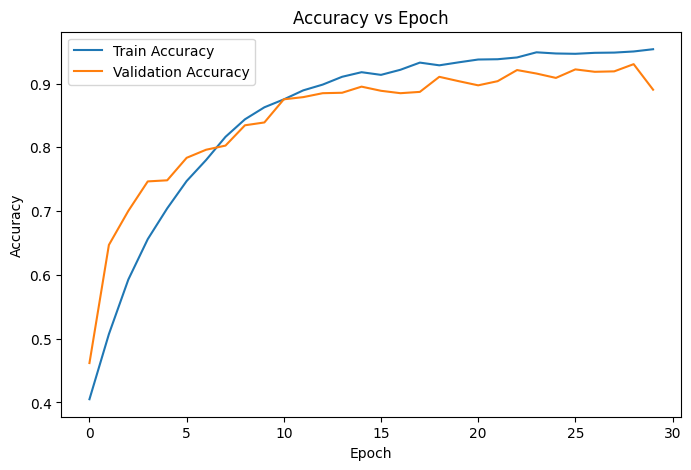

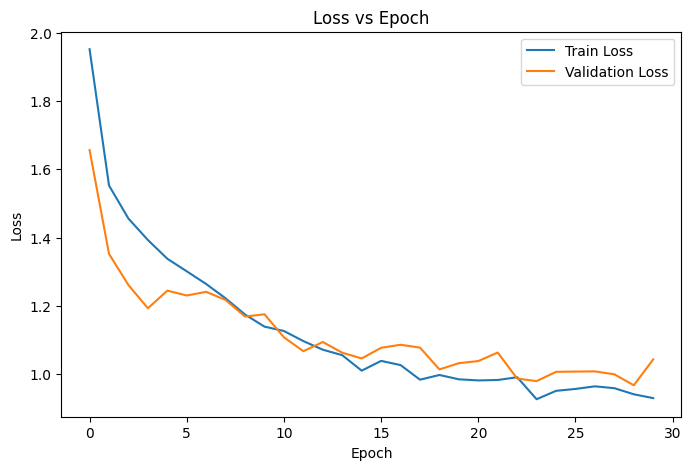

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


CONFUSION MATRIX

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 146ms/step


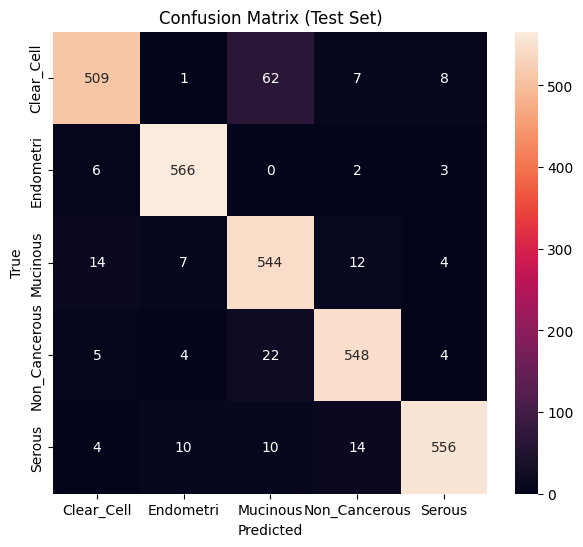

In [ ]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

# True labels
y_true = test_generator.classes

# Predictions
y_pred_probs = kk_net_model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# Class names
class_names = list(test_generator.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Test Set)")
plt.show()


CLASSIFICATION REPORT

In [ ]:
from sklearn.metrics import classification_report

print("\nClassification Report (Test Set):\n")
print(classification_report(y_true, y_pred, target_names=class_names))



Classification Report (Test Set):

               precision    recall  f1-score   support

   Clear_Cell       0.95      0.87      0.90       587
    Endometri       0.96      0.98      0.97       577
     Mucinous       0.85      0.94      0.89       581
Non_Cancerous       0.94      0.94      0.94       583
       Serous       0.97      0.94      0.95       594

     accuracy                           0.93      2922
    macro avg       0.93      0.93      0.93      2922
 weighted avg       0.93      0.93      0.93      2922



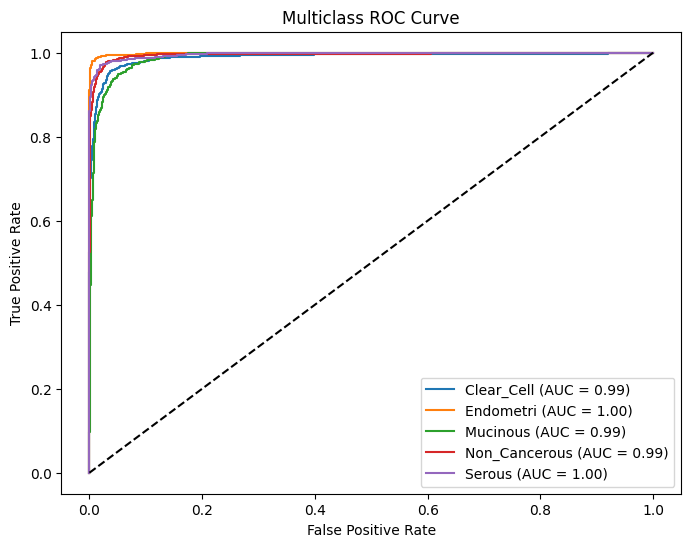

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

n_classes = len(class_names)

# Binarize true labels
y_true_bin = label_binarize(y_true, classes=range(n_classes))


plt.figure(figsize=(8,6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve')
plt.legend(loc='lower right')
plt.show()


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, rand_score

# =========================================
# 1. Get true labels + predictions from CNN
# =========================================

# True labels from test generator
y_true = test_generator.classes

# Predict probabilities
y_prob = kk_net_model.predict(test_generator)

# Convert probabilities → class labels
y_pred = np.argmax(y_prob, axis=1)

# =========================================
# 2. Confusion Matrix
# =========================================

cm = confusion_matrix(y_true, y_pred)

# =========================================
# 3. Advanced Metric Function (unchanged logic)
# =========================================

def calculate_advanced_metrics(cm):
    num_classes = cm.shape[0]
    metrics = {}

    for i in range(num_classes):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        tn = cm.sum() - (tp + fp + fn)

        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
        npv = tn / (tn + fn) if (tn + fn) > 0 else 0
        fdr = fp / (fp + tp) if (fp + tp) > 0 else 0

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f_measure = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

        numerator = (tp * tn) - (fp * fn)
        denominator = np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
        mcc = numerator / denominator if denominator > 0 else 0

        metrics[i] = {
            "Specificity": specificity,
            "FPR": fpr,
            "FNR": fnr,
            "NPV": npv,
            "FDR": fdr,
            "F-Measure": f_measure,
            "MCC": mcc
        }

    return metrics

# =========================================
# 4. Calculate Metrics
# =========================================

results = calculate_advanced_metrics(cm)

class_names = list(test_generator.class_indices.keys())

print(f"{'Category':<15} | {'Spec.':<6} | {'FPR':<6} | {'FNR':<6} | {'NPV':<6} | {'FDR':<6} | {'F-Meas':<7} | {'MCC':<6}")
print("-" * 90)

for i, cat in enumerate(class_names):
    m = results[i]
    print(f"{cat:<15} | {m['Specificity']:.3f} | {m['FPR']:.3f} | {m['FNR']:.3f} | {m['NPV']:.3f} | {m['FDR']:.3f} | {m['F-Measure']:.3f} | {m['MCC']:.3f}")

# =========================================
# 5. Rand Index (overall clustering similarity)
# =========================================

rand_index = rand_score(y_true, y_pred)
print(f"\nOverall Rand Index: {rand_index:.4f}")

92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 144ms/step
Category        | Spec.  | FPR    | FNR    | NPV    | FDR    | F-Meas  | MCC   
------------------------------------------------------------------------------------------
Clear_Cell      | 0.988 | 0.012 | 0.133 | 0.967 | 0.054 | 0.905 | 0.884
Endometri       | 0.991 | 0.009 | 0.019 | 0.995 | 0.037 | 0.972 | 0.965
Mucinous        | 0.960 | 0.040 | 0.064 | 0.984 | 0.147 | 0.893 | 0.866
Non_Cancerous   | 0.985 | 0.015 | 0.060 | 0.985 | 0.060 | 0.940 | 0.925
Serous          | 0.992 | 0.008 | 0.064 | 0.984 | 0.033 | 0.951 | 0.939

Overall Rand Index: 0.9484
